In [32]:
from sqlalchemy import create_engine, URL
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="@",
    host="localhost",
    database="retail_forecast"
)

engine = create_engine(connection_url)

In [37]:
# Pull the full view into a data frame 
query = "SELECT * FROM sales_summary_view;"
df = pd.read_sql(query,engine)

print(df.shape)
df.head()

(421570, 11)


,Store,Department,Date,Weekly_Sales,IsHoliday,Rolling_4wk_Avg,Current_Stock,Reorder_Point,Safety_Stock,Below_Reorder_Point,Trend_Based_Risk_Flag
0,1,1,2010-02-05,24924.50,0,24924.50,45042.69,67940.76,22914.11,1,1
1,1,1,2010-02-12,46039.49,1,35482.00,45042.69,67940.76,22914.11,1,1
2,1,1,2010-02-19,41595.55,0,37519.85,45042.69,67940.76,22914.11,1,1
3,1,1,2010-02-26,19403.54,0,32990.77,45042.69,67940.76,22914.11,1,1
4,1,1,2010-03-05,21827.90,0,32216.62,45042.69,67940.76,22914.11,1,1


In [8]:
# top 10 department by total_sales 
top_dept = df.groupby(['Store','Department'])['Weekly_Sales'].sum().reset_index().rename(columns={'Weekly_Sales':'Total_sales'}).sort_values('Total_sales',ascending=False).head(10)
top_dept

,Store,Department,Total_sales
1057,14,92,26101497.71
147,2,92,23572153.03
1523,20,92,23542625.04
980,13,92,23170876.20
297,4,92,22789210.43
1526,20,95,21537795.62
300,4,95,21054815.74
2061,27,92,20952094.22
1060,14,95,20655911.35
150,2,95,20533191.52


In [21]:
top_pairs = list(zip(top_dept['Store'], top_dept['Department']))
top_df = df[df.apply(lambda row: (row['Store'], row['Department']) in top_pairs, axis=1)] 

top_df.head()

,Store,Department,Date,Weekly_Sales,IsHoliday,Rolling_4wk_Avg,Current_Stock,Reorder_Point,Safety_Stock,Below_Reorder_Point,Trend_Based_Risk_Flag
19439,2,92,2010-02-05,178982.89,0,178982.89,514937.97,375501.45,45820.99,0,0
19440,2,92,2010-02-12,182142.89,1,180562.89,514937.97,375501.45,45820.99,0,0
19441,2,92,2010-02-19,170825.81,0,177317.20,514937.97,375501.45,45820.99,0,0
19442,2,92,2010-02-26,159343.07,0,172823.67,514937.97,375501.45,45820.99,0,0
19443,2,92,2010-03-05,163301.25,0,168903.26,514937.97,375501.45,45820.99,0,0


In [43]:
from prophet import Prophet

forecast_results = []

for store , dept in top_pairs:
    subset = top_df[(top_df['Store']==store) & (top_df['Department']==dept)].sort_values('Date')

    prophet_df = subset[['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})

    model = Prophet(weekly_seasonality=False,yearly_seasonality=True)
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=12,freq='W')

    forecast = model.predict(future)

    forecast['Store'] = store
    forecast['Department'] = dept 
    forecast_results.append(forecast[['Store', 'Department', 'ds', 'yhat', 'yhat_lower', 'yhat_upper']])

    print(f"Done: Store {store}, Dept {dept}")

19:36:13 - cmdstanpy - INFO - Chain [1] start processing
19:36:13 - cmdstanpy - INFO - Chain [1] done processing
19:36:13 - cmdstanpy - INFO - Chain [1] start processing


Done: Store 14, Dept 92


19:36:13 - cmdstanpy - INFO - Chain [1] done processing
19:36:13 - cmdstanpy - INFO - Chain [1] start processing


Done: Store 2, Dept 92


19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:14 - cmdstanpy - INFO - Chain [1] start processing


...

Done: Store 27, Dept 92


19:36:15 - cmdstanpy - INFO - Chain [1] done processing
19:36:16 - cmdstanpy - INFO - Chain [1] start processing


Done: Store 14, Dept 95


19:36:16 - cmdstanpy - INFO - Chain [1] done processing


Done: Store 2, Dept 95


In [44]:
all_forecasts = pd.concat(forecast_results,ignore_index=True)
print(all_forecasts.shape)
all_forecasts.tail(5)

(1550, 6)


,Store,Department,ds,yhat,yhat_lower,yhat_upper
1545,2,95,2012-12-16,152214.167242,143843.618923,160470.331778
1546,2,95,2012-12-23,153116.388215,144909.040278,160995.751090
1547,2,95,2012-12-30,146488.250302,138538.880853,154385.468852
1548,2,95,2013-01-06,137312.571744,128584.840010,145253.100359
1549,2,95,2013-01-13,133299.093007,125228.117303,141558.006855


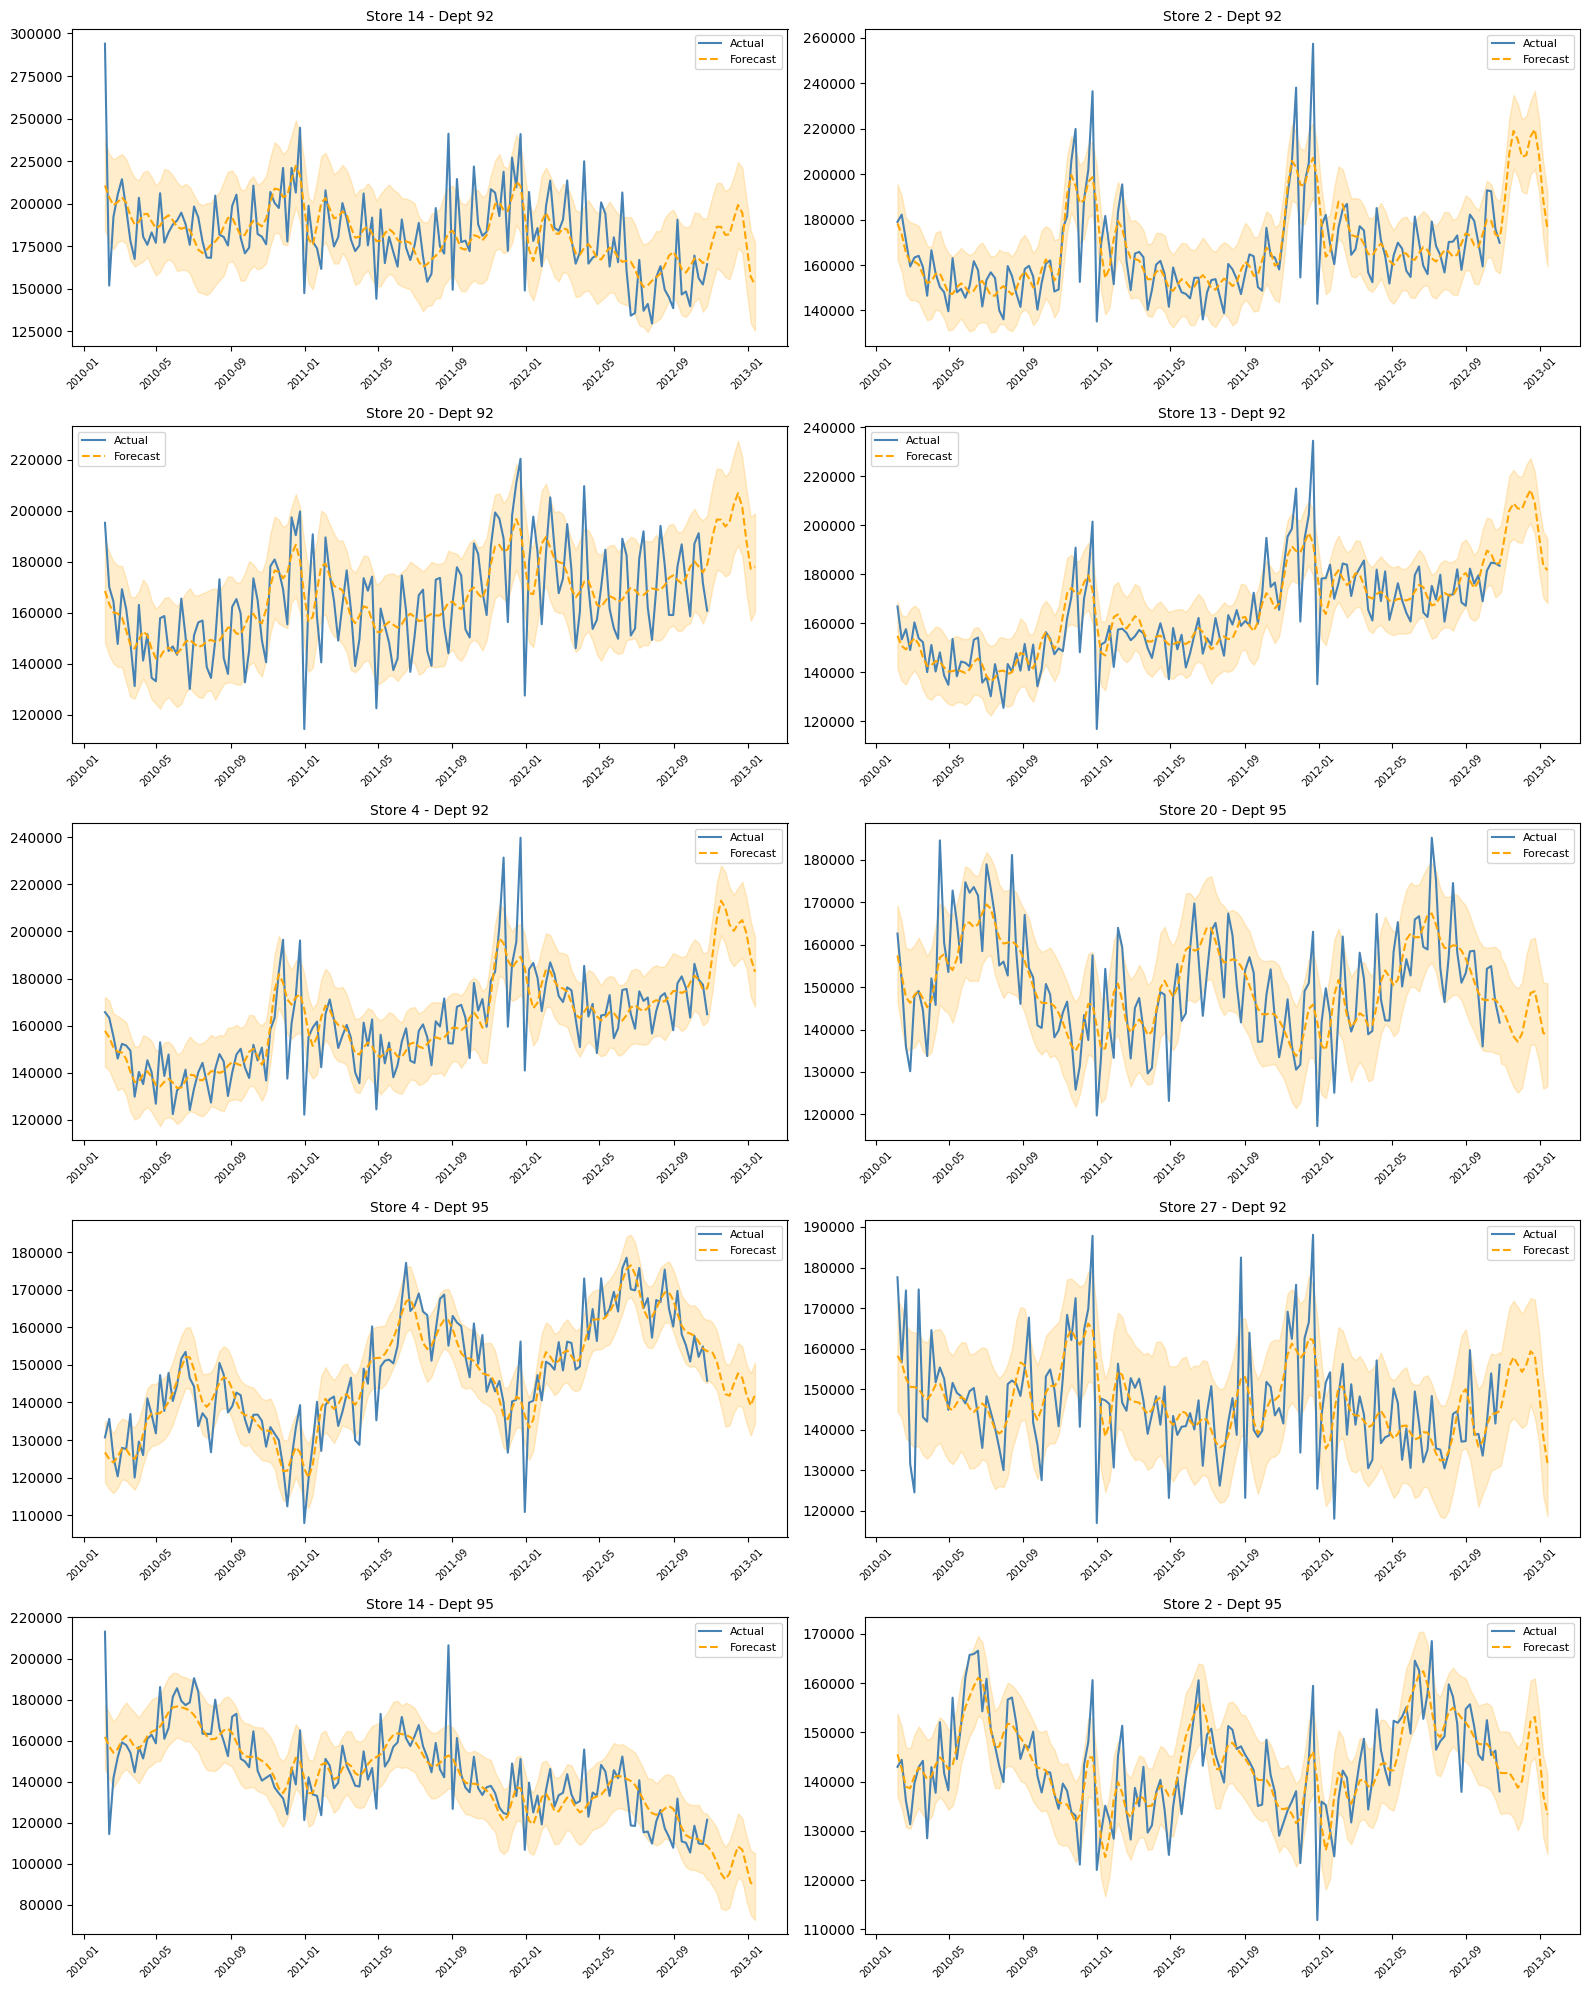

In [45]:
fig , axes = plt.subplots(5,2,figsize=(16,20))
axes = axes.flatten()

for i , (store,dept) in enumerate(top_pairs):
    ax = axes[i]
    #actual historical data  for this dept
    actual = top_df[(top_df['Store']==store) & (top_df['Department']==dept)].sort_values('Date')

    #forecast data for this dept 
    fc = all_forecasts[(all_forecasts['Store'] == store) & (all_forecasts['Department'] == dept)].sort_values('ds')

    ax.plot(actual['Date'],actual['Weekly_Sales'],label='Actual',color='steelblue')
    ax.plot(fc['ds'], fc['yhat'], label='Forecast', color='orange', linestyle='--') 
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], color='orange', alpha=0.2)

    ax.set_title(f'Store {store} - Dept {dept}', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)

plt.tight_layout()
plt.show()

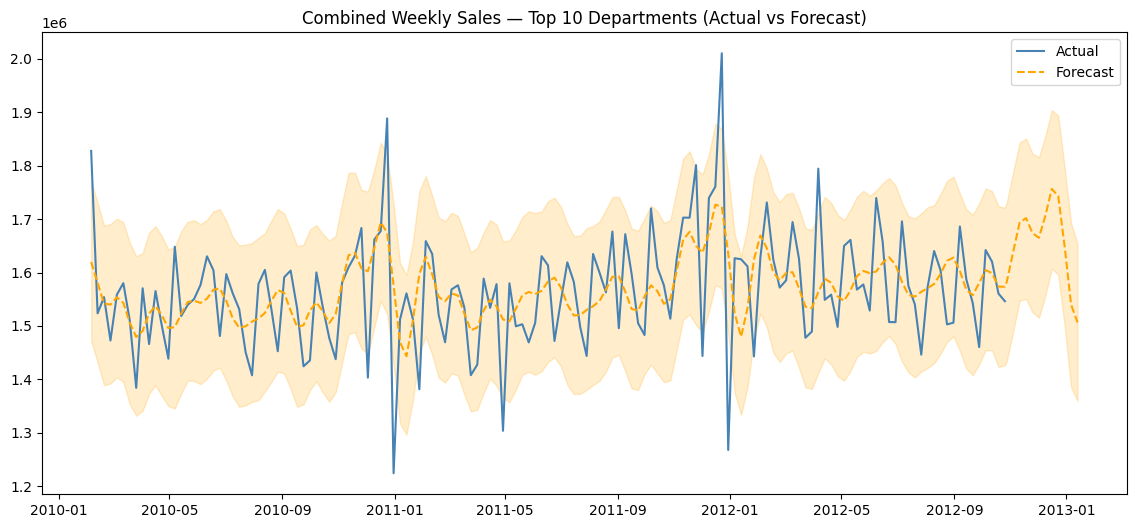

In [46]:
# Aggregate actual sales across all 10 departments, by date
actual_agg = top_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Aggregate forecast across all 10 departments, by date
forecast_agg = all_forecasts.groupby('ds')[['yhat', 'yhat_lower', 'yhat_upper']].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(actual_agg['Date'], actual_agg['Weekly_Sales'], label='Actual', color='steelblue')
plt.plot(forecast_agg['ds'], forecast_agg['yhat'], label='Forecast', color='orange', linestyle='--')
plt.fill_between(forecast_agg['ds'], forecast_agg['yhat_lower'], forecast_agg['yhat_upper'], color='orange', alpha=0.2)
plt.title('Combined Weekly Sales — Top 10 Departments (Actual vs Forecast)')
plt.legend()
plt.show()

In [47]:
# Detailed department-level export (forecast + inventory risk info)
inventory_lookup = df[['Store', 'Department', 'Current_Stock', 'Reorder_Point', 'Safety_Stock']].drop_duplicates()

final_export = all_forecasts.merge(inventory_lookup, on=['Store', 'Department'], how='left')
final_export.to_csv('forecast_output.csv', index=False)

print("Detailed export:", final_export.shape)
final_export.head()

Detailed export: (1550, 9)


,Store,Department,ds,yhat,yhat_lower,yhat_upper,Current_Stock,Reorder_Point,Safety_Stock
0,14,92,2010-02-05,210694.003775,184323.250405,237110.790798,442505.7,422427.34,57371.43
1,14,92,2010-02-12,203727.105770,177606.794879,229024.672559,442505.7,422427.34,57371.43
2,14,92,2010-02-19,199100.666536,173208.447285,225936.272185,442505.7,422427.34,57371.43
3,14,92,2010-02-26,200947.462993,177352.784362,227583.466516,442505.7,422427.34,57371.43
4,14,92,2010-03-05,203689.423644,178348.303863,229180.375599,442505.7,422427.34,57371.43


In [49]:
# Company-level (aggregated) export
actual_agg = top_df.groupby('Date')['Weekly_Sales'].sum().reset_index().rename(columns={'Date': 'ds', 'Weekly_Sales': 'Actual_Sales'})
forecast_agg = all_forecasts.groupby('ds')[['yhat', 'yhat_lower', 'yhat_upper']].sum().reset_index()

actual_agg['ds'] = pd.to_datetime(actual_agg['ds'])
forecast_agg['ds'] = pd.to_datetime(forecast_agg['ds']) 

company_export = forecast_agg.merge(actual_agg, on='ds', how='left')
company_export.to_csv('forecast_output_company_level.csv', index=False)

print("Company-level export:", company_export.shape)
company_export.head()

Company-level export: (155, 5)


,ds,yhat,yhat_lower,yhat_upper,Actual_Sales
0,2010-02-05,1.619803e+06,1.471752e+06,1.770688e+06,1827805.86
1,2010-02-12,1.580441e+06,1.431547e+06,1.730428e+06,1523590.68
2,2010-02-19,1.541837e+06,1.389066e+06,1.687830e+06,1553876.74
3,2010-02-26,1.539905e+06,1.392046e+06,1.690822e+06,1472688.06
4,2010-03-05,1.553556e+06,1.404130e+06,1.700873e+06,1558632.38


In [50]:
print(final_export.shape)
print(company_export.shape)
import os
print(os.getcwd())
print(os.listdir())

(1550, 9)
(155, 5)
C:\Users\gokup\OneDrive\Desktop\Walmart DA Project
['.ipynb_checkpoints', 'features.csv', 'forecast_output.csv', 'forecast_output_company_level.csv', 'stores.csv', 'train.csv', 'Walmart Sales Forecasting.ipynb']
